In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('/content/merged_customer_data.csv')

In [3]:
data.head()

,customer_id,age,annual_income,employment_length,employment_type,education,marital_status,num_dependents,application_id,application_hour,...,loan_to_annual_income,total_debt_amount,monthly_free_cash_flow,state,regional_unemployment_rate,regional_median_income,regional_median_rent,housing_price_index,cost_of_living_index,previous_zip_code
0,10000,41,$61800,2.2,Full-time,Graduate,Married,2,620515,5,...,0.286408,"159,913.10","3,819.23",OH,4.8,56000,1380.0,91.0,73.0,451
1,10001,38,"28,600",7.0,FULL_TIME,High School,Married,0,624978,4,...,3.986014,"189,932.20",$977.26,PA,4.4,61000,1510.0,92.0,87.0,537
2,10002,18,"$20,700",0.8,FULL_TIME,Bachelor,Single,0,564658,10,...,0.449275,31614.6,1203.12,VA,3.9,74000,1920.0,125.0,103.0,679
3,10003,27,"31,400",4.8,Full Time,Bachelor,Single,0,621493,7,...,0.277070,"$17,520.00",2093.4366666666665,CA,5.8,75000,1690.0,158.0,121.0,719
4,10004,26,$24600,5.2,Fulltime,High School,Single,0,637785,1,...,0.292683,"$31,453.60",1466.42,WA,5.8,78000,1700.0,152.0,127.0,933


In [4]:
df = data

Общая информация о DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89999 entries, 0 to 89998
Data columns (total 63 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 89999 non-null  int64  
 1   age                         89999 non-null  int64  
 2   annual_income               89999 non-null  object 
 3   employment_length           87746 non-null  float64
 4   employment_type             89999 non-null  object 
 5   education                   89999 non-null  object 
 6   marital_status              89999 non-null  object 
 7   num_dependents              89999 non-null  int64  
 8   application_id              89999 non-null  int64  
 9   application_hour            89999 non-null  int64  
 10  application_day_of_week     89999 non-null  int64  
 11  account_open_year           89999 non-null  int64  
 12  preferred_contact           89999 non-null  object 
 13  r

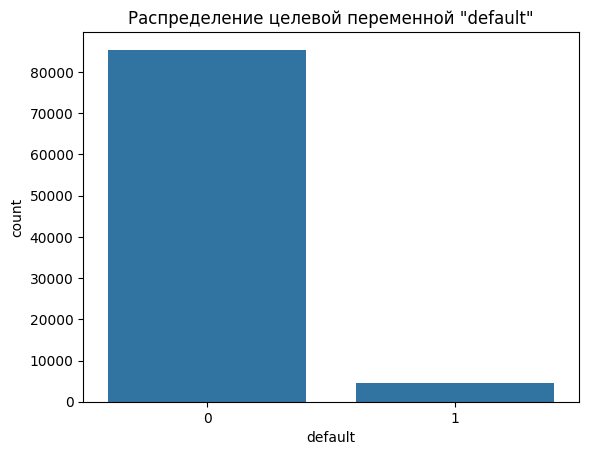

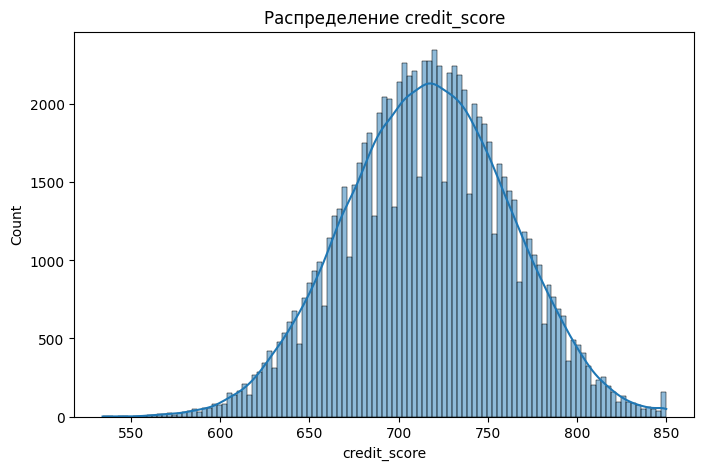

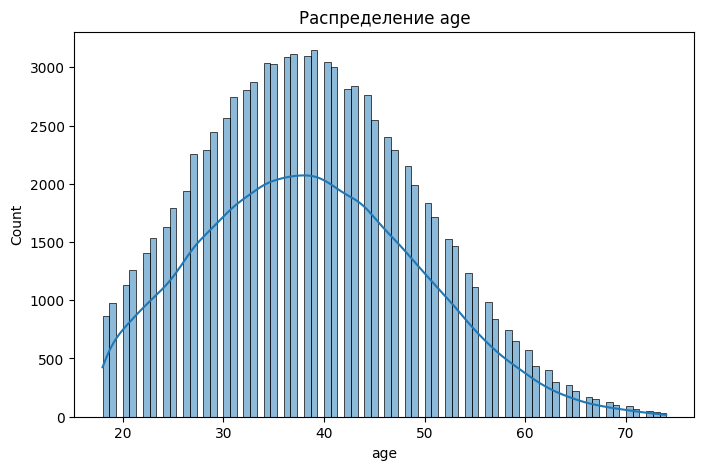

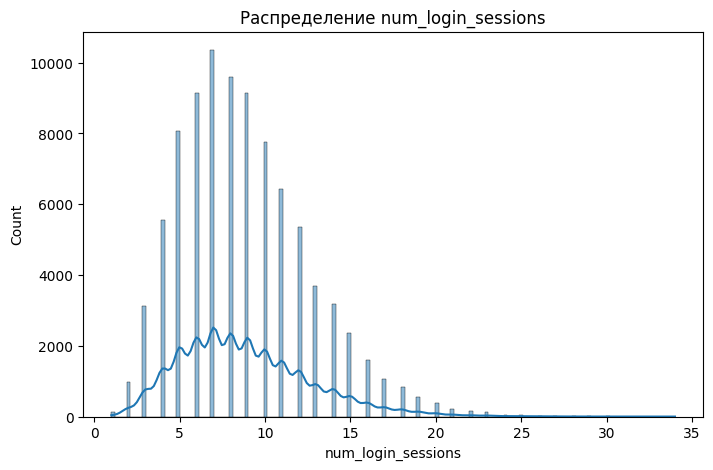

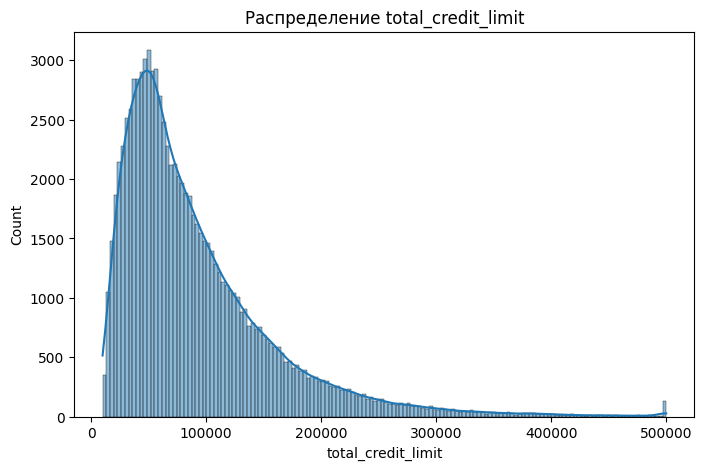

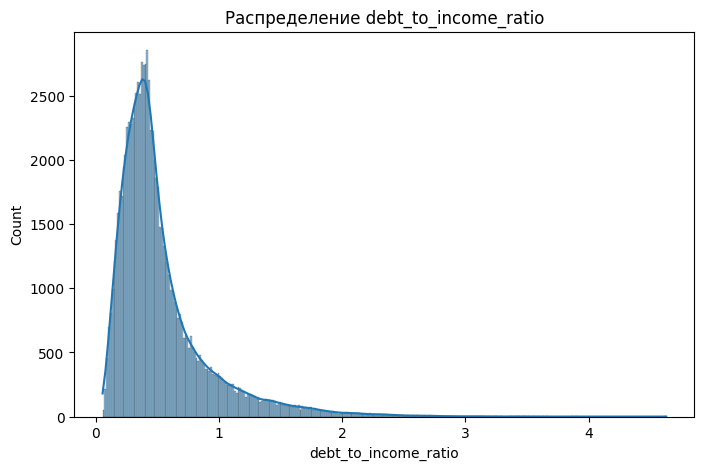

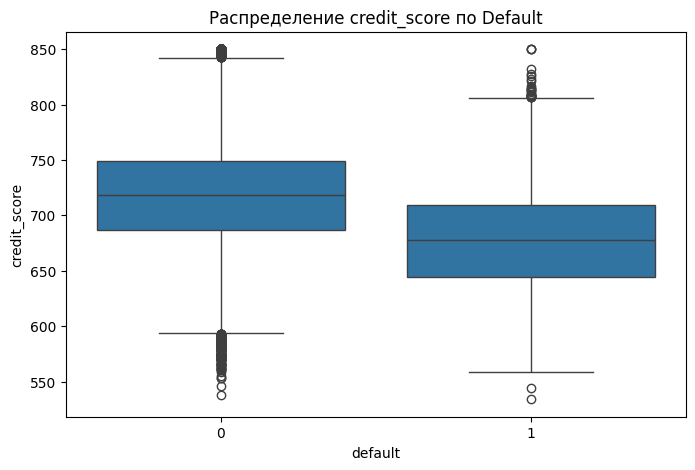

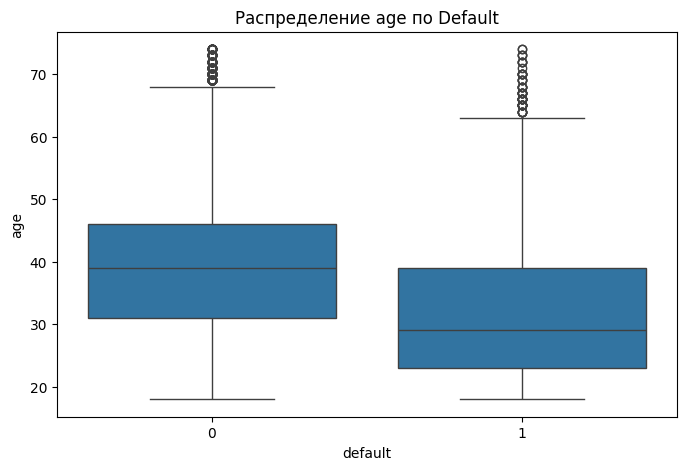

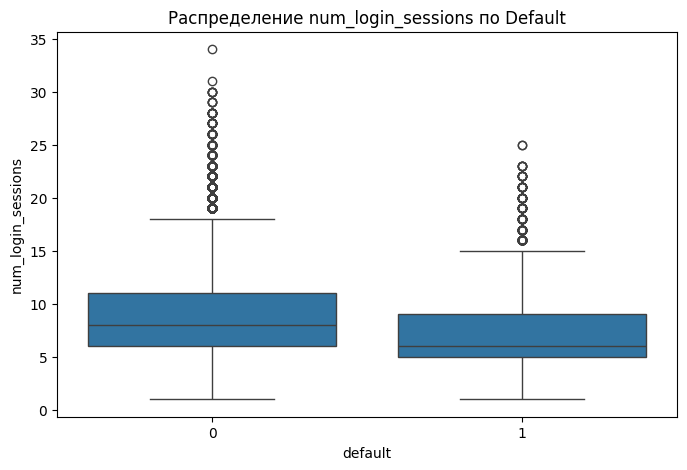

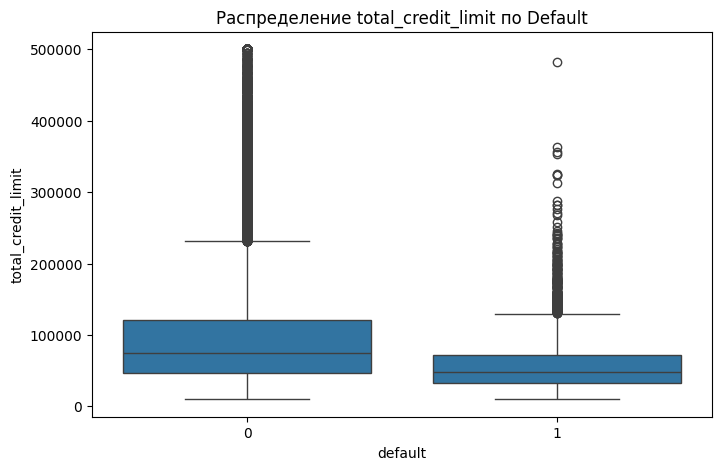

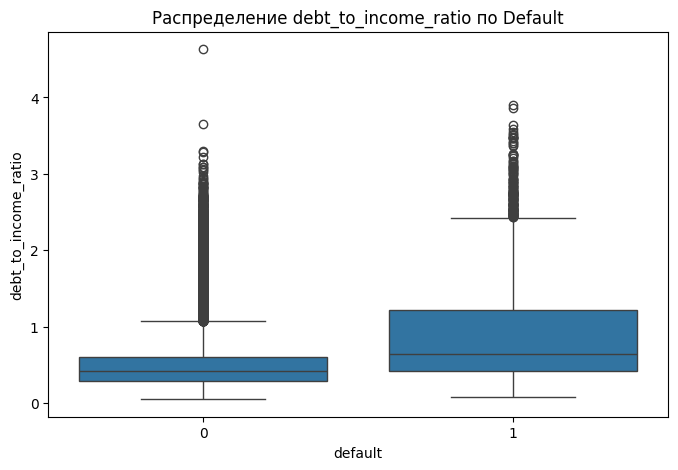

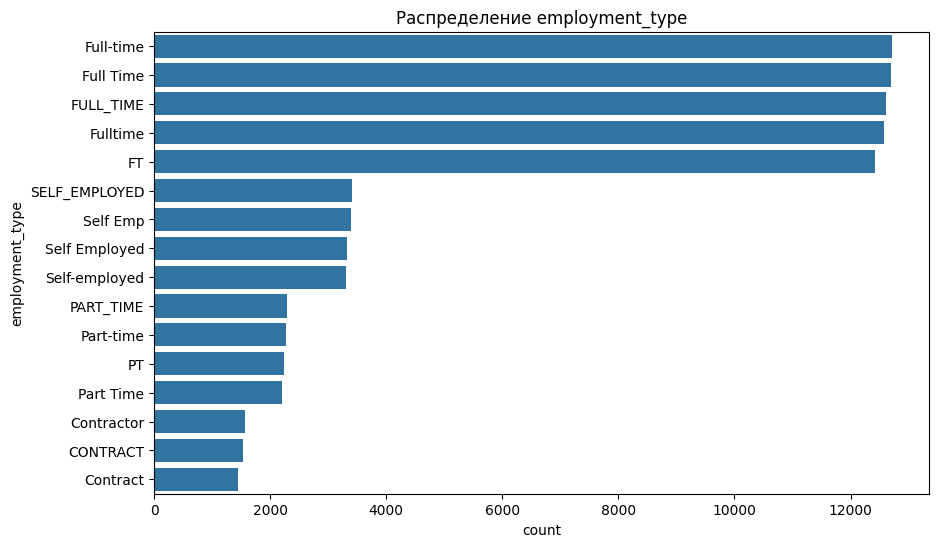

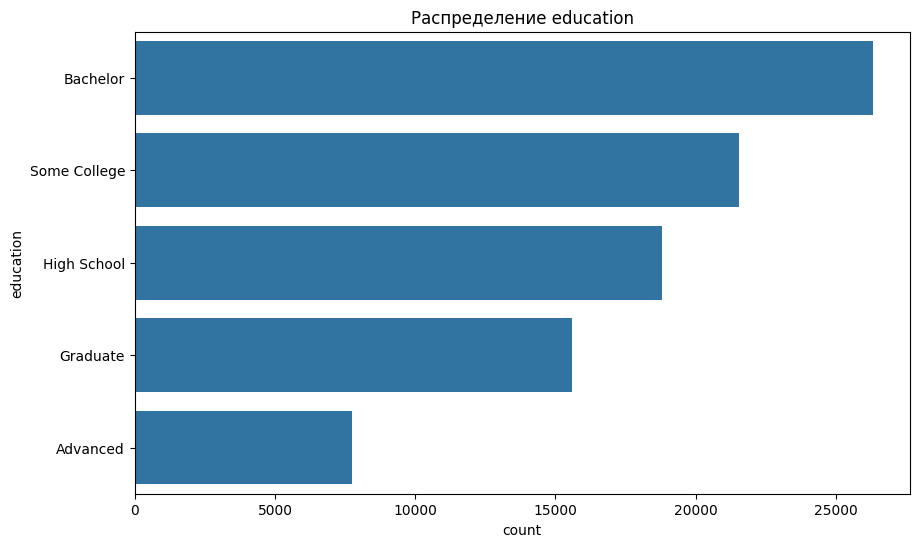

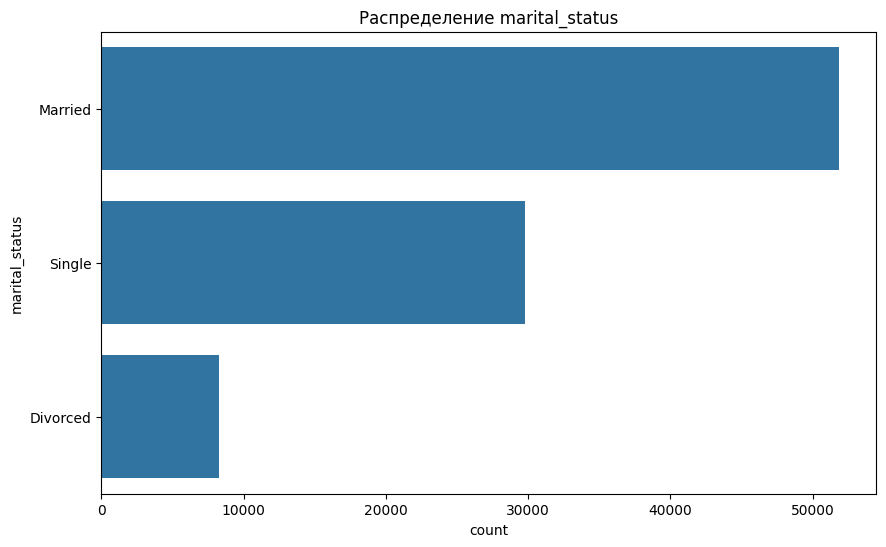

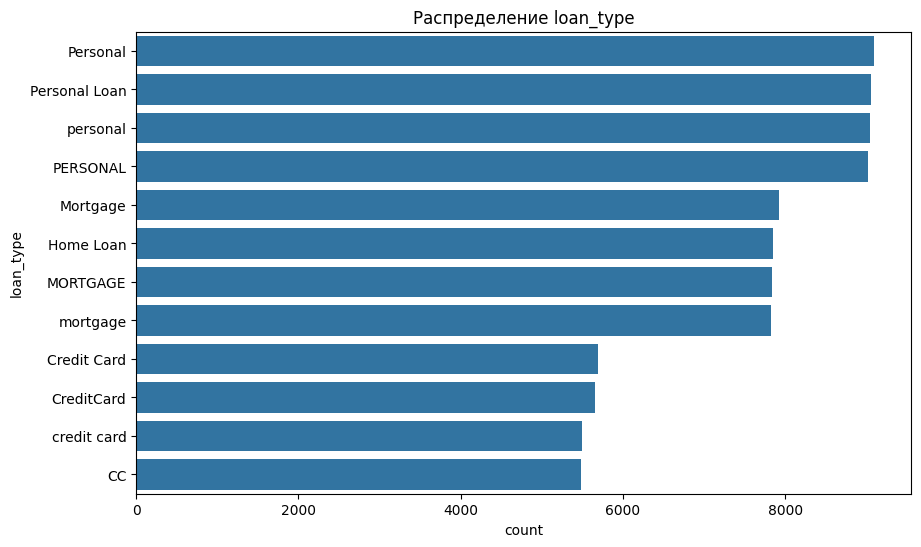

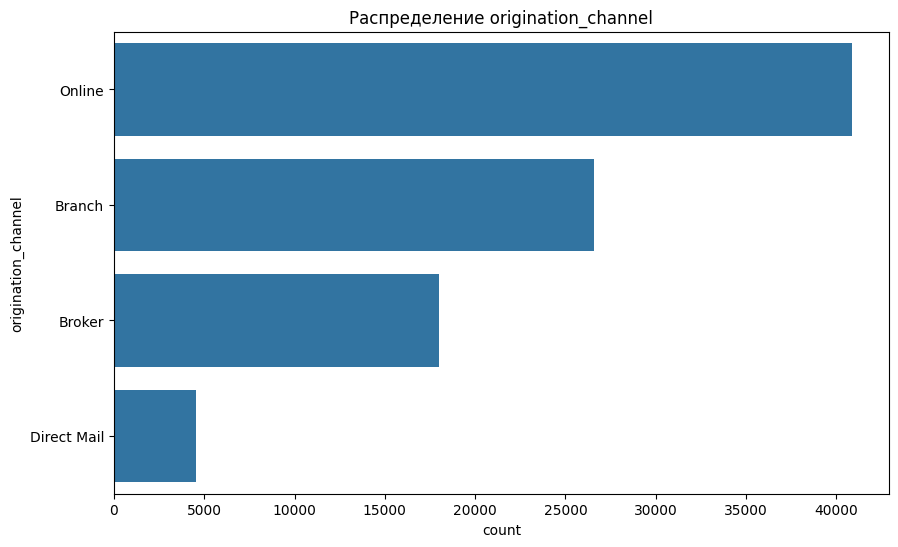

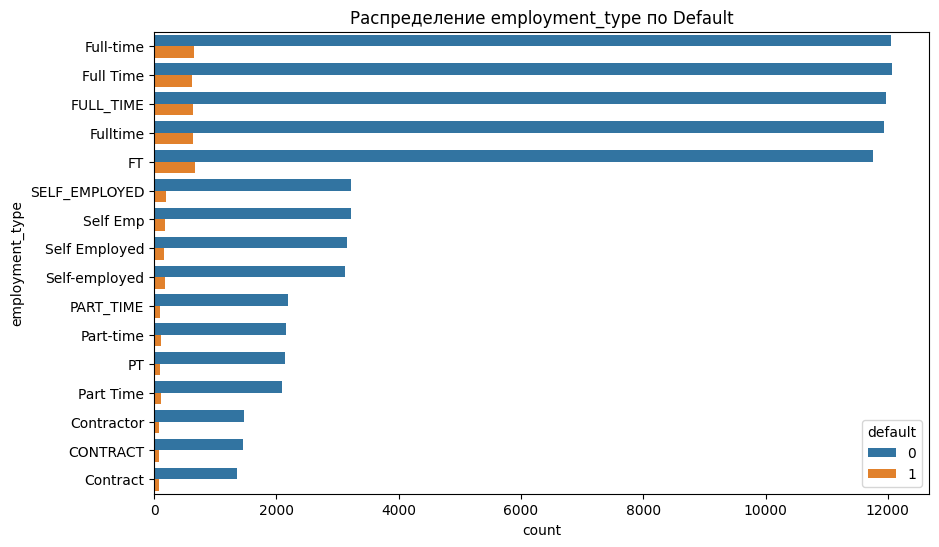

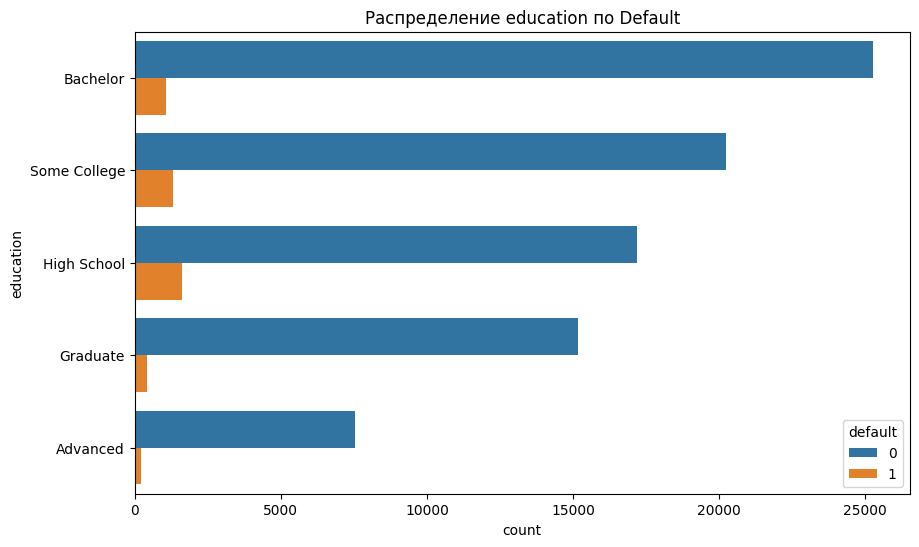

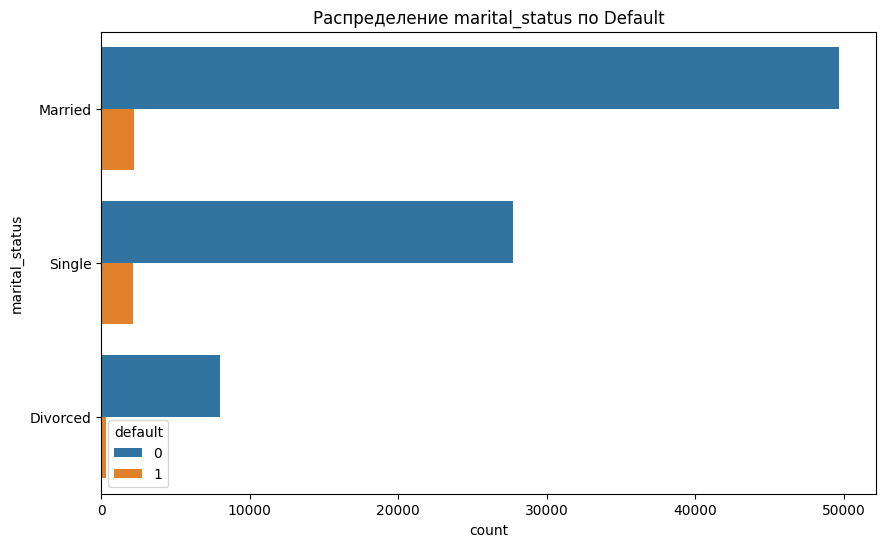

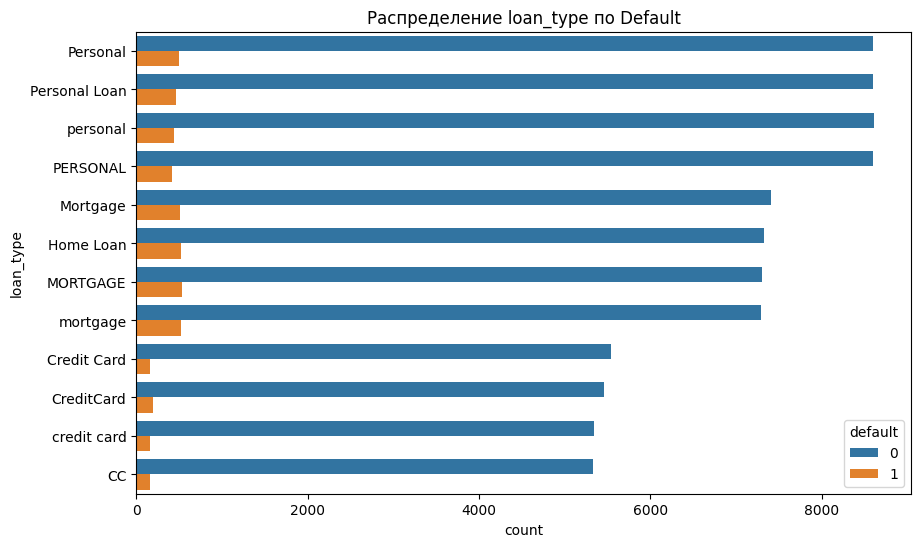

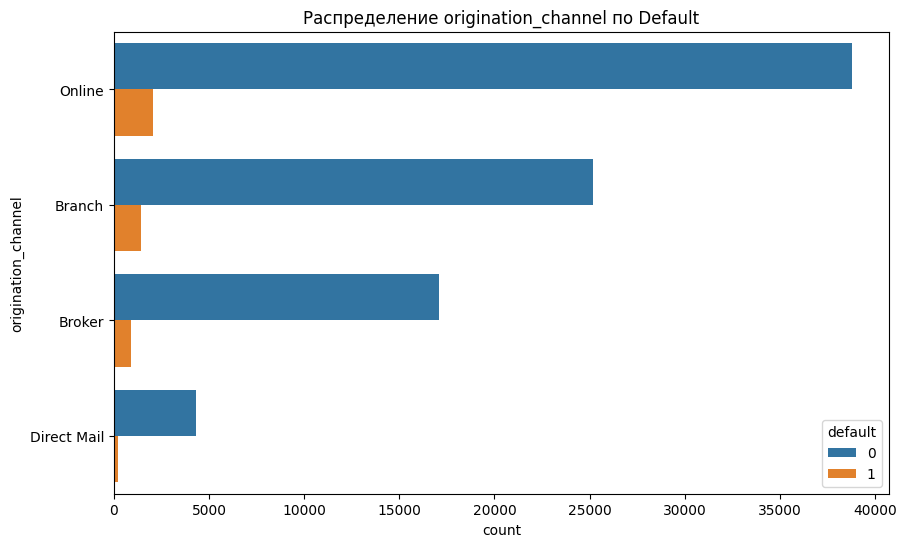

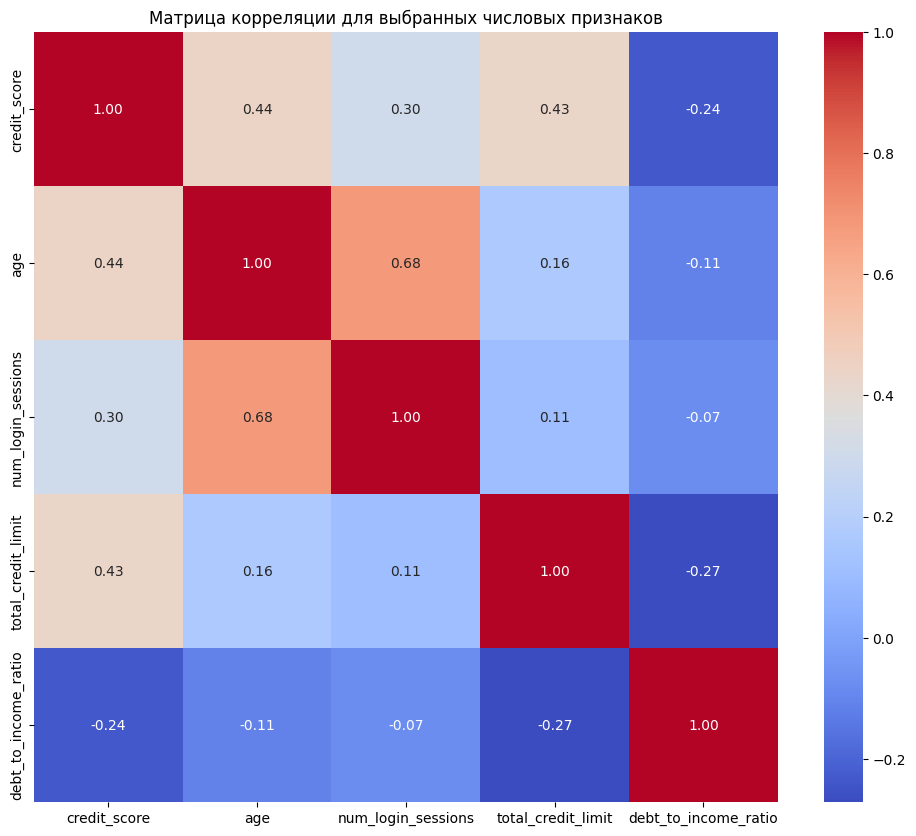

In [5]:
# 1. Общая информация о данных
print("Общая информация о DataFrame:")
df.info()
print("\n")

# 2. Описательная статистика для числовых признаков
print("Описательная статистика для числовых признаков:")
print(df.describe())
print("\n")

# 3. Количество уникальных значений для категориальных признаков
print("Количество уникальных значений для категориальных признаков:")
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].nunique()} уникальных значений")
print("\n")

# 4. Процент пропущенных значений
print("Процент пропущенных значений:")
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_info = pd.DataFrame({'Missing Count': missing_values, 'Missing %': missing_percentage})
print(missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing %', ascending=False))
print("\n")

# 5. Распределение целевой переменной 'default'
print("Распределение целевой переменной 'default':")
print(df['default'].value_counts(normalize=True))
sns.countplot(x='default', data=df)
plt.title('Распределение целевой переменной "default"')
plt.show()

# 6. Распределения числовых признаков (выборочно, для самых важных)
# Для примера возьмем credit_score, age, annual_income (после очистки)
# Для начала можно построить гистограммы для некоторых числовых столбцов,
# особенно тех, где есть предпосылки к аномалиям или интересным распределениям.
numerical_cols = ['credit_score', 'age', 'num_login_sessions', 'total_credit_limit', 'debt_to_income_ratio']
for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], kde=True)
    plt.title(f'Распределение {col}')
    plt.show()

# 7. Ящики с усами для числовых признаков по целевой переменной (выборочно)
# Это поможет увидеть различия в распределениях между дефолтными и недефолтными клиентами
for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='default', y=col, data=df)
    plt.title(f'Распределение {col} по Default')
    plt.show()

# 8. Распределения категориальных признаков (выборочно)
# Для примера возьмем employment_type, education, marital_status
categorical_cols = ['employment_type', 'education', 'marital_status', 'loan_type', 'origination_channel']
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.title(f'Распределение {col}')
    plt.show()

# 9. Взаимосвязь категориальных признаков с целевой переменной (выборочно)
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(y=col, hue='default', data=df, order=df[col].value_counts().index)
    plt.title(f'Распределение {col} по Default')
    plt.show()

# 10. Матрица корреляции для числовых признаков (если их не слишком много)
# Это может быть слишком много для 40+ числовых признаков, поэтому можно выбрать наиболее релевантные
# или построить после Feature Engineering
plt.figure(figsize=(12, 10))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Матрица корреляции для выбранных числовых признаков')
plt.show()

In [7]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
import re

# ========== CLEANING ==========

# 1. Удалить шумовые столбцы
df = df.drop(['random_noise_1', 'customer_id', 'application_id', 'loan_officer_id'], axis=1)

# 2. Очистка денежных столбцов (убрать $, запятые)
money_cols = ['annual_income', 'monthly_income', 'existing_monthly_debt',
              'monthly_payment', 'loan_amount', 'revolving_balance',
              'credit_usage_amount', 'available_credit',
              'total_monthly_debt_payment', 'total_debt_amount',
              'monthly_free_cash_flow']

def clean_money(x):
    if pd.isna(x):
        return np.nan
    x = str(x).replace('$', '').replace(',', '').strip()
    try:
        return float(x)
    except:
        return np.nan

for col in money_cols:
    df[col] = df[col].apply(clean_money)

# 3. Стандартизация категориальных
# employment_type
df['employment_type'] = df['employment_type'].str.upper().str.replace(' ', '_')
df['employment_type'] = df['employment_type'].replace({
    'FULL_TIME': 'FULL_TIME', 'FULLTIME': 'FULL_TIME', 'FT': 'FULL_TIME',
    'PART_TIME': 'PART_TIME', 'PT': 'PART_TIME',
    'SELF_EMPLOYED': 'SELF_EMPLOYED', 'SELF_EMP': 'SELF_EMPLOYED',
    'CONTRACT': 'CONTRACT', 'CONTRACTOR': 'CONTRACT'
})

# loan_type
df['loan_type'] = df['loan_type'].str.upper().str.replace(' ', '_')
df['loan_type'] = df['loan_type'].replace({
    'PERSONAL': 'PERSONAL', 'PERSONAL_LOAN': 'PERSONAL',
    'MORTGAGE': 'MORTGAGE', 'HOME_LOAN': 'MORTGAGE',
    'CREDIT_CARD': 'CREDIT_CARD', 'CREDITCARD': 'CREDIT_CARD', 'CC': 'CREDIT_CARD'
})

# account_status - все активные, удалить
df = df.drop(['account_status_code'], axis=1)

# 4. Импутация пропусков
# employment_length - MAR (зависит от возраста)
df['employment_length'] = df.groupby(['age', 'employment_type'])['employment_length'].transform(
    lambda x: x.fillna(x.median()))
df['employment_length'].fillna(df['employment_length'].median(), inplace=True)

# num_delinquencies_2yrs - MNAR (отсутствие = 0)
df['num_delinquencies_2yrs'].fillna(0, inplace=True)

# revolving_balance - MAR
df['revolving_balance'].fillna(df['revolving_balance'].median(), inplace=True)

# ========== FEATURE ENGINEERING ==========

# 1. Агрегация referral_code
df['has_referral'] = (df['referral_code'] != 'REF0000').astype(int)
df = df.drop(['referral_code'], axis=1)

# 2. Временные признаки
df['account_age'] = 2025 - df['account_open_year']
df['is_night_application'] = ((df['application_hour'] >= 22) | (df['application_hour'] <= 6)).astype(int)
df['is_weekend'] = (df['application_day_of_week'].isin([5, 6])).astype(int)

# 3. Финансовые коэффициенты (КРИТИЧНО!)
df['income_stability'] = df['employment_length'] / (df['age'] - 18 + 1)
df['debt_burden'] = df['existing_monthly_debt'] / df['monthly_income']
df['payment_stress'] = df['monthly_payment'] / df['monthly_income']
df['credit_pressure'] = df['credit_usage_amount'] / (df['total_credit_limit'] + 1)
df['free_cash_ratio'] = df['monthly_free_cash_flow'] / df['monthly_income']
df['loan_income_pressure'] = df['loan_amount'] / df['annual_income']
df['total_obligation_ratio'] = (df['existing_monthly_debt'] + df['monthly_payment']) / df['monthly_income']

# 4. Кредитные индикаторы риска
df['high_inquiries'] = (df['num_inquiries_6mo'] > 3).astype(int)
df['has_delinquencies'] = (df['num_delinquencies_2yrs'] > 0).astype(int)
df['has_public_records'] = (df['num_public_records'] > 0).astype(int)
df['credit_risk_score'] = (df['num_delinquencies_2yrs'] * 3 +
                            df['num_collections'] * 2 +
                            df['num_public_records'] * 5 +
                            df['high_inquiries'])

# 5. Поведенческие паттерны
df['low_engagement'] = ((df['num_login_sessions'] < 5) &
                        (df['has_mobile_app'] == 0)).astype(int)
df['high_service_calls'] = (df['num_customer_service_calls'] > 5).astype(int)

# 6. Региональные риски
df['high_unemployment_area'] = (df['regional_unemployment_rate'] > 5.5).astype(int)
df['low_income_area'] = (df['regional_median_income'] < 60000).astype(int)
df['expensive_area'] = (df['cost_of_living_index'] > 110).astype(int)

# 7. Бакетизация возраста
df['age_group'] = pd.cut(df['age'], bins=[0, 25, 35, 45, 55, 100],
                          labels=['very_young', 'young', 'middle', 'senior', 'old'])

# 8. Кредитный скор диапазоны
df['credit_score_range'] = pd.cut(df['credit_score'],
                                   bins=[0, 580, 670, 740, 850],
                                   labels=['poor', 'fair', 'good', 'excellent'])

# ========== ENCODING ==========
# Label Encoding для порядковых
le = LabelEncoder()
ordinal_cols = ['education', 'credit_score_range']
for col in ordinal_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# One-Hot для номинальных (только с малым количеством категорий)
nominal_cols = ['employment_type', 'marital_status', 'preferred_contact',
                'loan_type', 'loan_purpose', 'origination_channel', 'age_group']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

# Удалить высококардинальные
df = df.drop(['state', 'marketing_campaign', 'previous_zip_code'], axis=1)

print("Готово! Форма датасета:", df.shape)
print("\nПропуски:", df.isnull().sum().sum())

/tmp/ipython-input-2788824580.py:53: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['employment_length'].fillna(df['employment_length'].median(), inplace=True)
/tmp/ipython-input-2788824580.py:56: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].meth

Готово! Форма датасета: (89999, 95)

Пропуски: 0


In [8]:
!pip install catboost
!pip install lightgbm
!pip install xgboost
!pip install imblearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 10.2 MB/s eta 0:00:00


In [9]:
# Установка
!pip install catboost -q

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, recall_score
from imblearn.over_sampling import ADASYN
from imblearn.under_sampling import TomekLinks
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.preprocessing import PolynomialFeatures
from sklearn.calibration import CalibratedClassifierCV
import pickle

# ========== ШАГ 1: ФИЧИ ==========
print("Создание фичей...")

df['credit_age_inter'] = df['credit_score'] * df['age'] / 1000
df['risk_burden'] = df['credit_risk_score'] * df['debt_burden']
df['income_credit_ratio'] = df['annual_income'] / (df['credit_score'] + 1)
df['util_risk'] = df['credit_utilization'] * df['credit_risk_score']
df['regional_stress'] = df['regional_unemployment_rate'] * df['cost_of_living_index'] / 100

top_feat = ['credit_score', 'credit_risk_score', 'age', 'credit_utilization', 'debt_burden']
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
poly_feat = poly.fit_transform(df[top_feat])

poly_names = [f'{top_feat[i]}_X_{top_feat[j]}' for i in range(len(top_feat)) for j in range(i+1, len(top_feat))]
poly_df = pd.DataFrame(poly_feat[:, len(top_feat):], columns=poly_names)
df = pd.concat([df.reset_index(drop=True), poly_df.reset_index(drop=True)], axis=1)

print(f"✅ Размерность: {df.shape}")

# ========== ШАГ 2: ДАННЫЕ ==========
X = df.drop('default', axis=1)
y = df['default']
X.columns = X.columns.str.replace(' ', '_')

if X.columns.duplicated().any():
    X = X.loc[:, ~X.columns.duplicated()]

# ADASYN
print("\nБалансировка ADASYN + Tomek...")
adasyn = ADASYN(sampling_strategy=0.6, random_state=42)
X_res, y_res = adasyn.fit_resample(X.values, y.values)

# Tomek Links
tomek = TomekLinks()
X_res, y_res = tomek.fit_resample(X_res, y_res)

print(f"До: {y.value_counts().to_dict()}")
print(f"После: {pd.Series(y_res).value_counts().to_dict()}")

# ========== ШАГ 3: SPLIT ==========
X_train, X_val, y_train, y_val = train_test_split(
    X_res, y_res, test_size=0.2, stratify=y_res, random_state=42
)

X_orig_train, X_orig_test, y_orig_train, y_orig_test = train_test_split(
    X.values, y.values, test_size=0.2, stratify=y, random_state=42
)

# ========== ШАГ 4: XGBoost ==========
print("\n" + "="*60)
print("XGBoost...")
print("="*60)

xgb_model_es = xgb.XGBClassifier(
    scale_pos_weight=30,
    max_depth=10,
    learning_rate=0.002,
    n_estimators=5000,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=1,
    gamma=0,
    reg_alpha=0.1,
    reg_lambda=1,
    objective='binary:logistic',
    eval_metric='auc',
    early_stopping_rounds=150,
    random_state=42,
    tree_method='hist'
)

xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=300)

# Получаем лучшее количество итераций
best_iteration = xgb_model_es.best_iteration
print(f"\n✅ Лучшая итерация: {best_iteration}")



# ========== ШАГ 4.1: XGBoost БЕЗ EARLY STOPPING для калибровки ==========
print("\n" + "="*60)
print("Переобучаем XGBoost БЕЗ early stopping...")
print("="*60)

xgb_model = xgb.XGBClassifier(
    scale_pos_weight=30,
    max_depth=10,
    learning_rate=0.002,
    n_estimators=best_iteration,  # ФИКСИРОВАННОЕ количество!
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=1,
    gamma=0,
    reg_alpha=0.1,
    reg_lambda=1,
    objective='binary:logistic',
    random_state=42,
    tree_method='hist'
)

# Обучаем на всех balanced данных
X_all_balanced = np.vstack([X_train, X_val])
y_all_balanced = np.concatenate([y_train, y_val])

xgb_model.fit(X_all_balanced, y_all_balanced, verbose=False)
print("✅ Модель переобучена")



# ========== ШАГ 5: LightGBM ==========
print("\n" + "="*60)
print("LightGBM...")
print("="*60)

lgb_model = lgb.LGBMClassifier(
    is_unbalance=True,
    max_depth=10,
    learning_rate=0.002,
    n_estimators=5000,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_samples=10,
    reg_alpha=0.1,
    reg_lambda=1,
    class_weight={0: 1, 1: 30},
    random_state=42,
    verbose=-1
)

lgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(150), lgb.log_evaluation(300)])

# ========== ШАГ 6: CatBoost ==========
print("\n" + "="*60)
print("CatBoost...")
print("="*60)

cat_model = CatBoostClassifier(
    auto_class_weights='Balanced',
    depth=10,
    learning_rate=0.002,
    iterations=5000,
    l2_leaf_reg=1,
    border_count=254,
    random_seed=42,
    early_stopping_rounds=150,
    verbose=300
)

cat_model.fit(X_train, y_train, eval_set=(X_val, y_val))

# ========== ШАГ 7: КАЛИБРОВКА ==========
print("\nКалибровка XGBoost...")
calibrated = CalibratedClassifierCV(xgb_model, method='isotonic', cv=5)
calibrated.fit(X_train, y_train)

# ========== ШАГ 8: ПОИСК ПОРОГА ==========
print("\n" + "="*60)
print("ПОИСК ПОРОГА ДЛЯ 98%/98%")
print("="*60)

y_proba = calibrated.predict_proba(X_orig_test)[:, 1]

best_threshold = 0.5
best_score = 0

# Ищем где оба класса > 98%
for threshold in np.arange(0.05, 0.95, 0.005):
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_orig_test, y_pred)

    class_0_acc = cm[0,0] / (cm[0,0] + cm[0,1]) if (cm[0,0] + cm[0,1]) > 0 else 0
    class_1_acc = cm[1,1] / (cm[1,0] + cm[1,1]) if (cm[1,0] + cm[1,1]) > 0 else 0
    balanced_acc = (class_0_acc + class_1_acc) / 2

    if class_0_acc >= 0.98 and class_1_acc >= 0.98:
        if balanced_acc > best_score:
            best_score = balanced_acc
            best_threshold = threshold
            print(f"✅ Порог: {threshold:.4f} | C0: {class_0_acc:.4f} | C1: {class_1_acc:.4f}")

# Если не нашли, берем лучший баланс
if best_score == 0:
    print("\n⚠️ Ищем лучший баланс...")
    for threshold in np.arange(0.05, 0.95, 0.005):
        y_pred = (y_proba >= threshold).astype(int)
        cm = confusion_matrix(y_orig_test, y_pred)

        class_0_acc = cm[0,0] / (cm[0,0] + cm[0,1]) if (cm[0,0] + cm[0,1]) > 0 else 0
        class_1_acc = cm[1,1] / (cm[1,0] + cm[1,1]) if (cm[1,0] + cm[1,1]) > 0 else 0
        balanced_acc = (class_0_acc + class_1_acc) / 2

        if balanced_acc > best_score:
            best_score = balanced_acc
            best_threshold = threshold

# ========== ШАГ 9: РЕЗУЛЬТАТЫ ==========
y_final_pred = (y_proba >= best_threshold).astype(int)
final_auc = roc_auc_score(y_orig_test, y_proba)

print("\n" + "="*60)
print("ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ")
print("="*60)
print(f"🎯 AUC: {final_auc:.4f}")
print(f"📊 Порог: {best_threshold:.4f}")
print("\n" + classification_report(y_orig_test, y_final_pred, digits=4))

cm = confusion_matrix(y_orig_test, y_final_pred)
print(f"\nConfusion Matrix:\n{cm}")

class_0_acc = cm[0,0] / (cm[0,0] + cm[0,1])
class_1_acc = cm[1,1] / (cm[1,0] + cm[1,1])

print(f"\n📈 Class 0 Accuracy: {class_0_acc:.4f} ({class_0_acc*100:.2f}%)")
print(f"📈 Class 1 Recall: {class_1_acc:.4f} ({class_1_acc*100:.2f}%)")
print(f"📊 Balanced: {(class_0_acc + class_1_acc)/2:.4f}")

# ========== СОХРАНЕНИЕ ==========
final_model = {
    'model': calibrated,
    'threshold': best_threshold,
    'features': X.columns.tolist(),
    'auc': final_auc,
    'class_0_acc': class_0_acc,
    'class_1_acc': class_1_acc
}

with open('final_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

print("\n✅ СОХРАНЕНО: final_model.pkl")
print(f"🏆 AUC: {final_auc:.4f} | C0: {class_0_acc*100:.1f}% | C1: {class_1_acc*100:.1f}%")

Создание фичей...
✅ Размерность: (89999, 110)

Балансировка ADASYN + Tomek...
До: {0: 85405, 1: 4594}
После: {0: 85068, 1: 52046}

XGBoost...
[0]	validation_0-auc:0.95705
[300]	validation_0-auc:0.97960
[600]	validation_0-auc:0.98205
[900]	validation_0-auc:0.98362
[1200]	validation_0-auc:0.98457
[1500]	validation_0-auc:0.98500
[1800]	validation_0-auc:0.98519
[2100]	validation_0-auc:0.98531
[2400]	validation_0-auc:0.98539
[2700]	validation_0-auc:0.98543
[3000]	validation_0-auc:0.98548
[3300]	validation_0-auc:0.98550
[3387]	validation_0-auc:0.98550


NameError: name 'xgb_model_es' is not defined